# 第4章 多层感知机（MLP）

本章从线性模型出发，引入隐藏层与激活函数构建多层感知机，并系统讨论训练深层网络所需的核心技术：
隐藏层、激活函数、模型选择、欠拟合与过拟合、权重衰减（L2 正则化）、Dropout、前向传播与反向传播、参数初始化

> 参考：[动手学深度学习 v2 · 第4章](https://zh-v2.d2l.ai/chapter_multilayer-perceptrons/index.html)

In [4]:
import torch
import torch.nn as nn
from torch.utils import data
import torchvision
from torchvision import transforms
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

print(f'PyTorch 版本: {torch.__version__}')

PyTorch 版本: 2.8.0+cu126


---
### 4.1 多层感知机

从线性回归到多层感知机（MLP），其实就是在解决一个问题，就是如何拟合非线性关系。这在[前馈神经网络.md](../MachineLearning/18_NN/前馈神经网络.md)中已经详细介绍了。本质就是加层进行深度化。

这里又引入了一个**关键问题**：仿射函数的仿射函数仍是仿射函数——无论堆叠多少线性层，等价于一个线性层，无法拟合非线性关系。

**解决方案**：在层间插入**非线性激活函数** $\sigma$，打破线性性。





**MLP 数学表达**

以单隐藏层 MLP 为例（输入维度 $d$，隐藏层 $h$ 个单元，输出 $q$ 类）：

$$\mathbf{H} = \sigma(\mathbf{X}\mathbf{W}^{(1)} + \mathbf{b}^{(1)})  \qquad \mathbf{H}\in\mathbb{R}^{n\times h}$$

$$\mathbf{O} = \mathbf{H}\mathbf{W}^{(2)} + \mathbf{b}^{(2)}  \qquad \mathbf{O}\in\mathbb{R}^{n\times q}$$

激活函数决定了网络的非线性特性，下面逐一介绍并可视化三种常用激活函数。激活函数 $\sigma$ **逐元素**作用于隐藏层，赋予网络非线性表达能力。

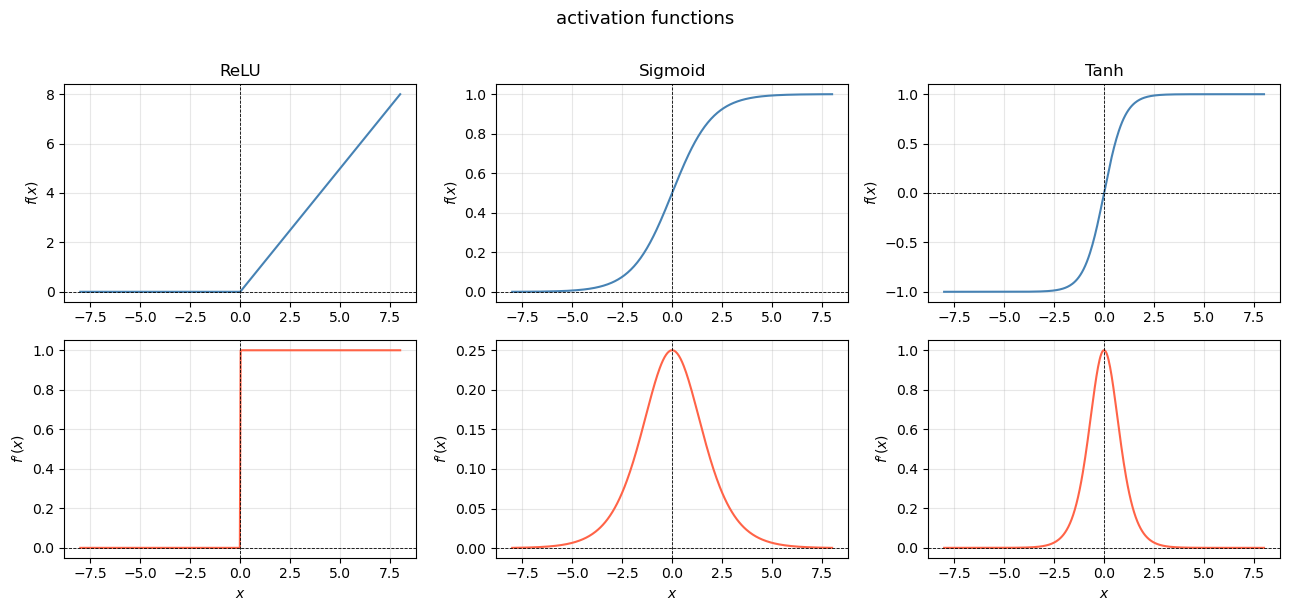

In [5]:
x = torch.linspace(-8, 8, 400, requires_grad=True)

def plot_activation(ax_f, ax_d, y, title):
    """绘制激活函数及其导数"""
    y_sum = y.sum()
    y_sum.backward()
    grad = x.grad.clone().detach().numpy()  # clone() 避免 zero_() 清掉数据
    x.grad.zero_()

    xn = x.detach().numpy()
    yn = y.detach().numpy()
    ax_f.plot(xn, yn, color='steelblue')
    ax_f.set_title(title, fontsize=12)
    ax_f.axhline(0, color='k', lw=0.6, ls='--')
    ax_f.axvline(0, color='k', lw=0.6, ls='--')
    ax_f.set_ylabel('$f(x)$')
    ax_f.grid(True, alpha=0.3)

    ax_d.plot(xn, grad, color='tomato')
    ax_d.axhline(0, color='k', lw=0.6, ls='--')
    ax_d.axvline(0, color='k', lw=0.6, ls='--')
    ax_d.set_ylabel("$f'(x)$")
    ax_d.set_xlabel('$x$')
    ax_d.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 3, figsize=(13, 6))

# ReLU
plot_activation(axes[0,0], axes[1,0], torch.relu(x), 'ReLU')

# Sigmoid
plot_activation(axes[0,1], axes[1,1], torch.sigmoid(x), 'Sigmoid')

# Tanh
plot_activation(axes[0,2], axes[1,2], torch.tanh(x), 'Tanh')

fig.suptitle('activation functions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**三种激活函数对比：**

| 激活函数 | 公式 | 值域 | 导数最大值 | 特点 |
|---------|------|------|-----------|------|
| **ReLU** | $\max(0, x)$ | $[0, +\infty)$ | 1 | 计算简单，缓解梯度消失；负区间梯度为 0（神经元死亡问题）|
| **Sigmoid** | $\frac{1}{1+e^{-x}}$ | $(0, 1)$ | 0.25 | 输出可解释为概率；两端导数趋 0（梯度消失）|
| **Tanh** | $\frac{e^x - e^{-x}}{e^x + e^{-x}}$ | $(-1, 1)$ | 1 | 零中心化，比 sigmoid 收敛快；仍有梯度消失问题 |

---
### 4.2 MLP 的简洁实现（PyTorch）

使用 `nn.Sequential` 搭建两层 MLP，在 Fashion-MNIST 上进行图像分类。

**加载数据**

In [ ]:
def load_data_fashion_mnist(batch_size):
    trans = transforms.ToTensor()
    train_set = torchvision.datasets.FashionMNIST(
        root='../data', train=True,  transform=trans, download=True)
    test_set  = torchvision.datasets.FashionMNIST(
        root='../data', train=False, transform=trans, download=True)
    train_iter = data.DataLoader(train_set, batch_size, shuffle=True,  num_workers=0)
    test_iter  = data.DataLoader(test_set,  batch_size, shuffle=False, num_workers=0)
    return train_iter, test_iter

batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size)

**定义 MLP**

In [7]:
net = nn.Sequential(
    nn.Flatten(),          # (B, 1, 28, 28) -> (B, 784)
    nn.Linear(784, 256),   # 第一隐藏层
    nn.ReLU(),
    nn.Linear(256, 10)     # 输出层（10 类）
)

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, std=0.01)
        nn.init.zeros_(m.bias)

net.apply(init_weights)
print(net)
print(f'\n可训练参数量: {sum(p.numel() for p in net.parameters()):,}')

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=10, bias=True)
)

可训练参数量: 203,530


**训练与评估**

In [8]:
def accuracy(y_hat, y):
    return (y_hat.argmax(dim=1) == y).float().sum().item()

def evaluate_accuracy(net, data_iter):
    net.eval()
    correct, total = 0.0, 0
    with torch.no_grad():
        for X, y in data_iter:
            correct += accuracy(net(X), y)
            total += y.numel()
    return correct / total

def train(net, train_iter, test_iter, num_epochs, lr):
    loss_fn  = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(num_epochs):
        net.train()
        total_loss, correct, total = 0.0, 0.0, 0
        for X, y in train_iter:
            optimizer.zero_grad()
            y_hat = net(X)
            l = loss_fn(y_hat, y)
            l.backward()
            optimizer.step()
            total_loss += l.item() * y.numel()
            correct    += accuracy(y_hat, y)
            total      += y.numel()

        tr_loss = total_loss / total
        tr_acc  = correct / total
        te_acc  = evaluate_accuracy(net, test_iter)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)
        print(f'epoch {epoch+1:2d}  loss {tr_loss:.4f}  '
              f'train acc {tr_acc:.3f}  test acc {te_acc:.3f}')
    return history

history_mlp = train(net, train_iter, test_iter, num_epochs=10, lr=0.1)

epoch  1  loss 1.0390  train acc 0.647  test acc 0.712
epoch  2  loss 0.6001  train acc 0.789  test acc 0.787
epoch  3  loss 0.5222  train acc 0.817  test acc 0.807
epoch  4  loss 0.4801  train acc 0.832  test acc 0.824
epoch  5  loss 0.4562  train acc 0.840  test acc 0.817
epoch  6  loss 0.4324  train acc 0.848  test acc 0.836
epoch  7  loss 0.4206  train acc 0.851  test acc 0.843
epoch  8  loss 0.4048  train acc 0.857  test acc 0.839
epoch  9  loss 0.3928  train acc 0.861  test acc 0.820
epoch 10  loss 0.3844  train acc 0.864  test acc 0.851


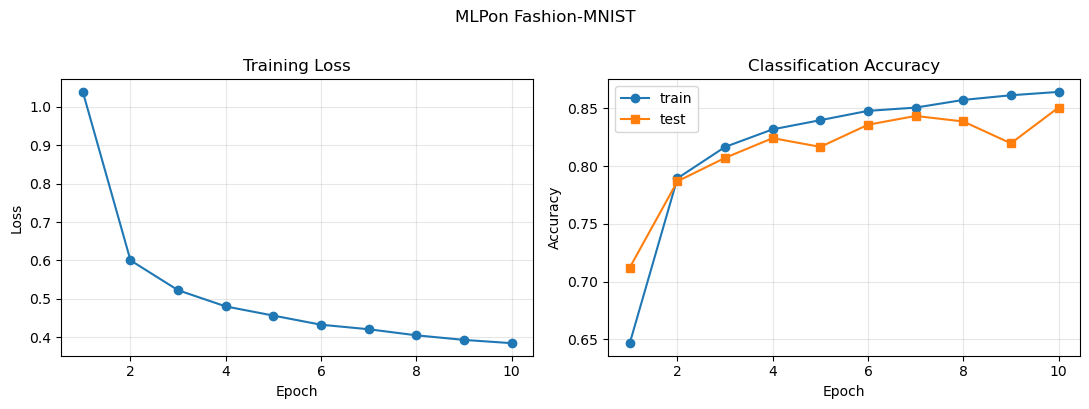

In [12]:
epochs = range(1, 11)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs, history_mlp['train_loss'], marker='o')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history_mlp['train_acc'], marker='o', label='train')
axes[1].plot(epochs, history_mlp['test_acc'],  marker='s', label='test')
axes[1].set_title('Classification Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('MLPon Fashion-MNIST', y=1.01)
plt.tight_layout(); plt.show()

---
### 4.3 模型选择、欠拟合与过拟合


- **训练误差**：模型在训练集上的损失，可通过优化持续降低
- **泛化误差**：模型在未见数据上的期望损失，是真正关心的目标
- **欠拟合（underfitting）**：训练误差和测试误差都高 → 模型过于简单
- **过拟合（overfitting）**：训练误差 $\ll$ 测试误差 → 模型记住了训练集噪声

| 因素 | 增大过拟合风险 |
|------|---------------|
| 参数数量 | 参数越多，风险越大 |
| 参数取值范围 | 权重值越大，风险越大 |
| 训练样本量 | 样本越少，风险越大 |

---
### 4.4 权重衰减（Weight Decay）


权重衰减是最常用的正则化技术，通过在损失函数中加入 **L2 范数惩罚项**限制参数取值范围：

$$\tilde{L}(\mathbf{w}, b) = L(\mathbf{w}, b) + \frac{\lambda}{2}\|\mathbf{w}\|^2$$

其中 $\lambda \geq 0$ 控制正则化强度。对应的梯度更新变为：

$$\mathbf{w} \leftarrow \underbrace{(1 - \eta\lambda)}_{\text{权重衰减因子}} \mathbf{w} - \frac{\eta}{|\mathcal{B}|}\sum_{i\in\mathcal{B}} \nabla_{\mathbf{w}} L^{(i)}$$

每次更新前权重乘以 $(1-\eta\lambda) < 1$，因此称为**权重衰减**。

---
### 4.5 Dropout


Dropout 在训练中以概率 $p$ **随机将隐藏单元置零**，并对保留的单元做**缩放补偿**，保证期望不变：

$$h' = \begin{cases} 0 & \text{以概率 } p \\ \dfrac{h}{1-p} & \text{以概率 } 1-p \end{cases}$$

因此 $\mathbb{E}[h'] = h$。**测试时关闭 dropout**，使用完整网络做预测。

![dropout](assets/dropout2.svg)

**直觉**：迫使网络不依赖任意一组神经元，学习冗余、鲁棒的特征表示。等价于训练了大量共享参数的子网络的集成。

In [22]:
# 可视化 dropout 的效果
torch.manual_seed(42)
h = torch.arange(1, 9, dtype=torch.float32)  # 8 个神经元的激活值

def dropout_layer(X, p):
    assert 0 <= p <= 1
    if p == 1: return torch.zeros_like(X)
    if p == 0: return X
    mask = (torch.rand(X.shape) > p).float()
    return mask * X / (1.0 - p)

print('原始激活:', h.numpy())
print('dropout=0.0:', dropout_layer(h, 0.0).numpy())
print('dropout=0.5:', dropout_layer(h, 0.5).numpy())
print('dropout=1.0:', dropout_layer(h, 1.0).numpy())

原始激活: [1. 2. 3. 4. 5. 6. 7. 8.]
dropout=0.0: [1. 2. 3. 4. 5. 6. 7. 8.]
dropout=0.5: [ 2.  4.  0.  8.  0. 12.  0. 16.]
dropout=1.0: [0. 0. 0. 0. 0. 0. 0. 0.]


In [23]:
# 使用 nn.Dropout 实现（靠近输入层用较小 p，深层用较大 p）
dropout1, dropout2 = 0.2, 0.5

net_drop = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256), nn.ReLU(),
    nn.Dropout(dropout1),          # 第一隐藏层后
    nn.Linear(256, 256), nn.ReLU(),
    nn.Dropout(dropout2),          # 第二隐藏层后
    nn.Linear(256, 10)
)

net_drop.apply(init_weights)
print(net_drop)
print(f'\n可训练参数量: {sum(p.numel() for p in net_drop.parameters()):,}')

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.5, inplace=False)
  (7): Linear(in_features=256, out_features=10, bias=True)
)

可训练参数量: 269,322


epoch  1  loss 0.3415  train acc 0.874  test acc 0.847
epoch  2  loss 0.3344  train acc 0.876  test acc 0.827
epoch  3  loss 0.3297  train acc 0.878  test acc 0.867
epoch  4  loss 0.3202  train acc 0.881  test acc 0.844
epoch  5  loss 0.3179  train acc 0.883  test acc 0.868
epoch  6  loss 0.3087  train acc 0.886  test acc 0.866
epoch  7  loss 0.3055  train acc 0.886  test acc 0.863
epoch  8  loss 0.2999  train acc 0.888  test acc 0.866
epoch  9  loss 0.2947  train acc 0.891  test acc 0.880
epoch 10  loss 0.2957  train acc 0.890  test acc 0.870


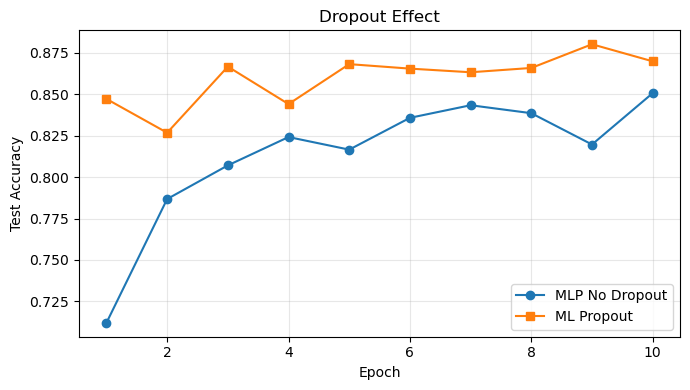

In [25]:
history_drop = train(net_drop, train_iter, test_iter, num_epochs=10, lr=0.5)

# 与无 dropout 的 MLP 对比
fig, ax = plt.subplots(figsize=(7, 4))
epochs = range(1, 11)
ax.plot(epochs, history_mlp['test_acc'],  marker='o', label='MLP No Dropout')
ax.plot(epochs, history_drop['test_acc'], marker='s', label='ML Propout')
ax.set_xlabel('Epoch'); ax.set_ylabel('Test Accuracy')
ax.set_title('Dropout Effect')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
### 4.6 前向传播与反向传播

**前向传播**

以含 L2 正则的单隐藏层 MLP 为例，设输入 $\mathbf{x}$，正则系数 $\lambda$：

| 步骤 | 公式 |
|------|------|
| 隐藏层线性 | $\mathbf{z} = \mathbf{W}^{(1)}\mathbf{x} + \mathbf{b}^{(1)}$ |
| 激活 | $\mathbf{h} = \phi(\mathbf{z})$ |
| 输出层线性 | $\mathbf{o} = \mathbf{W}^{(2)}\mathbf{h} + \mathbf{b}^{(2)}$ |
| 损失 | $l = \text{CrossEntropy}(\mathbf{o}, y)$ |
| 正则项 | $s = \frac{\lambda}{2}(\|\mathbf{W}^{(1)}\|_F^2 + \|\mathbf{W}^{(2)}\|_F^2)$ |
| 目标 | $J = l + s$ |

**反向传播**

链式法则**从输出层往回**计算每个参数的梯度：

$$\frac{\partial J}{\partial \mathbf{o}} = \frac{\partial l}{\partial \mathbf{o}}$$

$$\frac{\partial J}{\partial \mathbf{W}^{(2)}} = \frac{\partial J}{\partial \mathbf{o}} \mathbf{h}^\top + \lambda \mathbf{W}^{(2)}$$

$$\frac{\partial J}{\partial \mathbf{h}} = \left(\mathbf{W}^{(2)}\right)^\top \frac{\partial J}{\partial \mathbf{o}}$$

$$\frac{\partial J}{\partial \mathbf{z}} = \frac{\partial J}{\partial \mathbf{h}} \odot \phi'(\mathbf{z})$$

$$\frac{\partial J}{\partial \mathbf{W}^{(1)}} = \frac{\partial J}{\partial \mathbf{z}} \mathbf{x}^\top + \lambda \mathbf{W}^{(1)}$$

**训练内存远大于推理内存**：中间变量（$\mathbf{z}$、$\mathbf{h}$ 等）在前向传播时必须保留，用于反向传播计算梯度。

---
### 4.7 模型初始化

**梯度消失与梯度爆炸**

在 $L$ 层网络中，反向传播的梯度包含 $L$ 个矩阵的乘积：

$$\frac{\partial \mathbf{o}}{\partial \mathbf{W}^{(l)}} = \mathbf{M}^{(L)} \cdots \mathbf{M}^{(l+1)} \mathbf{v}^{(l)}$$

- **梯度消失**：若每层 $\|\mathbf{M}^{(i)}\| < 1$（如 sigmoid 的导数最大仅 0.25），乘积指数级趋零，早期层参数几乎不更新。
- **梯度爆炸**：若每层 $\|\mathbf{M}^{(i)}\| > 1$，乘积指数级膨胀，优化不稳定。

为了解决这一问题，研究者提出的思路是进行恰当的参数初始化，也就是让输入与参数相乘后，通过控制输出的方差，尽量避免落到梯度消失或者爆炸的位置，这里介绍两类初始化方法。

**Xavier 初始化：** 核心思想保持每层输出方差与输入方差相同（前向和反向传播均满足）。

对于全连接层（输入维度 $n_{\text{in}}$，输出维度 $n_{\text{out}}$），Xavier 初始化权重满足：

$$\sigma = \sqrt{\frac{2}{n_{\text{in}} + n_{\text{out}}}}$$

**两种实现：**
- 高斯：$\mathbf{W} \sim \mathcal{N}\left(0,\ \frac{2}{n_{\text{in}}+n_{\text{out}}}\right)$
- 均匀：$\mathbf{W} \sim \mathcal{U}\left(-\sqrt{\frac{6}{n_{\text{in}}+n_{\text{out}}}},\ \sqrt{\frac{6}{n_{\text{in}}+n_{\text{out}}}}\right)$

In [ ]:
# PyTorch 内置初始化方法示例
net_init = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256), nn.ReLU(),
    nn.Linear(256, 256), nn.ReLU(),
    nn.Linear(256, 10)
)

def init_demo(m):
    if isinstance(m, nn.Linear):
        # Xavier 均匀初始化（适合 tanh/sigmoid）
        nn.init.xavier_uniform_(m.weight)
        # Kaiming 正态初始化（适合 ReLU）
        # nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
        nn.init.zeros_(m.bias)
        print(f'  {m}  权重方差: {m.weight.data.var():.6f}')

print('Xavier 均匀初始化后各层权重方差：')
net_init.apply(init_demo)

**Kaiming 初始化（He 初始化）**

Xavier 初始化假设激活函数在零点附近近似线性（如 tanh/sigmoid），但 ReLU 会将一半的值置零，导致方差缩小一半。Kaiming 初始化针对这一点做了修正：

$$W \sim \mathcal{N}\!\left(0,\;\frac{2}{n_{\text{in}}}\right) \quad \text{(fan\_in 模式)}$$

分子从 Xavier 的 $1$ 变为 $2$，正好**补偿 ReLU 砍掉一半激活值带来的方差衰减**。

| 初始化方法 | 适用激活函数 | 方差 |
|-----------|------------|------|
| Xavier | tanh / sigmoid | $\frac{1}{n_{\text{in}}}$ |
| Kaiming | ReLU / LeakyReLU | $\frac{2}{n_{\text{in}}}$ |

PyTorch 用法：
```python
nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
```
- `mode='fan_in'`：保证**前向传播**方差稳定（更常用）
- `mode='fan_out'`：保证**反向传播**梯度方差稳定

> 简单记忆：用 ReLU → 用 Kaiming；用 tanh/sigmoid → 用 Xavier。